In [1]:
import pandas as pd

df = pd.read_excel("C:/Users/DELL/Downloads/hotel_daily_booking_data_2024_2025.xlsx",skiprows=1)
df['date'] = pd.to_datetime(df['date'])

In [2]:
df.head()

,date,room_type,bookings,price_inr,occupancy_pct,event_flag,event_name,day_of_week,is_weekend
0,2024-01-01,Deluxe,57,16000,89.7,1,New Year,Monday,0
1,2024-01-01,Suite,14,30650,64.5,1,New Year,Monday,0
2,2024-01-01,Standard,83,11350,86.8,1,New Year,Monday,0
3,2024-01-02,Deluxe,51,12950,81.6,0,NaN,Tuesday,0
4,2024-01-02,Suite,13,24150,61.5,0,NaN,Tuesday,0


In [3]:
#room_counts = df.groupby(["room_type"])['room_type'].count()

In [4]:
#room_counts

In [5]:
print(df.shape)

(2193, 9)


In [6]:
df = df.sort_values(['room_type','date'])

In [7]:
df['month'] = df['date'].dt.month
#df['day'] = df['date'].dt.day
df['week'] = df['date'].dt.isocalendar().week.astype(int)

In [8]:
df = df.sort_values(['room_type', 'date'])

df['lag_1'] = df.groupby('room_type')['bookings'].shift(1)


df['lag_7'] = df.groupby('room_type')['bookings'].shift(7)


df['rolling_7'] =  df.groupby('room_type')['bookings'].transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())

df['price_lag_1']      = df.groupby('room_type')['price_inr'].shift(1)
df['price_lag_7']      = df.groupby('room_type')['price_inr'].shift(7)
df['price_rolling_7']  = df.groupby('room_type')['price_inr'].transform(lambda x: x.shift(1).rolling(7).mean())


df = df.dropna(subset=['lag_1', 'lag_7', 'rolling_7', 'price_lag_1', 'price_lag_7', 'price_rolling_7'])


In [9]:
#df[(df['room_type'].isin(['Deluxe','Suite'])) & (df['date']<='2024-01-08')]
df[['lag_1', 'lag_7', 'rolling_7', 'price_lag_1', 'price_lag_7', 'price_rolling_7']].isna().sum()

lag_1              0
lag_7              0
rolling_7          0
price_lag_1        0
price_lag_7        0
price_rolling_7    0
dtype: int64

In [10]:
#df.head()

In [11]:
from sklearn.preprocessing import LabelEncoder
encoders = {}
for col in ['room_type','day_of_week']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

df = pd.get_dummies(df,columns=['event_name'],drop_first=True)

In [12]:
print(encoders['day_of_week'].classes_)
print(encoders['room_type'].classes_)
print(encoders)

['Friday' 'Monday' 'Saturday' 'Sunday' 'Thursday' 'Tuesday' 'Wednesday']
['Deluxe' 'Standard' 'Suite']
{'room_type': LabelEncoder(), 'day_of_week': LabelEncoder()}


In [13]:
for col, le in encoders.items():
    mapping = dict(zip(le.transform(le.classes_), le.classes_))
    print(f"{col}: {mapping}")


room_type: {np.int64(0): 'Deluxe', np.int64(1): 'Standard', np.int64(2): 'Suite'}
day_of_week: {np.int64(0): 'Friday', np.int64(1): 'Monday', np.int64(2): 'Saturday', np.int64(3): 'Sunday', np.int64(4): 'Thursday', np.int64(5): 'Tuesday', np.int64(6): 'Wednesday'}


In [14]:
##rows = []
##for col, le in encoders.items():
   ## for encoded, original in zip(le.transform(le.classes_), le.classes_):
        ##rows.append({'column': col, 'encoded': encoded, 'original': original})

##pd.DataFrame(rows).to_excel("C:/Users/DELL/Downloads/label_encoding_mapping.xlsx", index=False)
#print("Saved ✅")


# ── Inverse transform later ──────────────────────────────────────────────────
print(encoders['room_type'].inverse_transform([0, 1, 2]))    # → ['Deluxe', 'Standard', 'Suite']
print(encoders['day_of_week'].inverse_transform([0, 1, 2,3,4,5,6]))  # → ['Friday', 'Monday', 'Saturday']


['Deluxe' 'Standard' 'Suite']
['Friday' 'Monday' 'Saturday' 'Sunday' 'Thursday' 'Tuesday' 'Wednesday']


In [15]:
#future['room_type'] = encoders['room_type'].inverse_transform(future['room_type'])
#encoders['room_type'].inverse_transform(future['room_type'])


In [16]:
print(df.columns)

Index(['date', 'room_type', 'bookings', 'price_inr', 'occupancy_pct',
       'event_flag', 'day_of_week', 'is_weekend', 'month', 'week', 'lag_1',
       'lag_7', 'rolling_7', 'price_lag_1', 'price_lag_7', 'price_rolling_7',
       'event_name_Diwali', 'event_name_New Year', 'event_name_Tamil New Year',
       'event_name_Valentine's Day'],
      dtype='object')


In [17]:
df = df.sort_values(['room_type', 'date'])

In [18]:
cutoff_date = (df['date'].max() - pd.Timedelta(days=30))
train_df = df[df['date'] <= cutoff_date]
val_df = df[df['date'] > cutoff_date]

print(cutoff_date)
print(train_df['date'].min(), train_df['date'].max())
print(val_df['date'].min(), val_df['date'].max())

2025-12-01 00:00:00
2024-01-08 00:00:00 2025-12-01 00:00:00
2025-12-02 00:00:00 2025-12-31 00:00:00


In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

# ── Step 1: Compute VIF on training data ─────────────────────────────────────
exog_candidates = [
    'is_weekend', 'month', 'week',
    'price_lag_1', 'price_lag_7', 'price_rolling_7',
    'event_name_Diwali', 'event_name_New Year',
    'event_name_Tamil New Year', "event_name_Valentine's Day"
]

# Use Deluxe train as representative sample for VIF
sample = train_df[train_df['room_type'] == 0][exog_candidates].astype(float)

def compute_vif(df):
    vif = pd.DataFrame()
    vif['feature'] = df.columns
    vif['VIF'] = [variance_inflation_factor(df.values, i) 
                  for i in range(df.shape[1])]
    return vif.sort_values('VIF', ascending=False).reset_index(drop=True)

print("── VIF Before Selection ─────────────────────────────────────────────")
print(compute_vif(sample))

# ── Step 2: Drop features with VIF > 10 iteratively ──────────────────────────
def select_features_vif(df, threshold=10):
    cols = list(df.columns)
    while True:
        vif = compute_vif(df[cols])
        max_vif = vif['VIF'].max()
        if max_vif > threshold:
            drop_col = vif.loc[vif['VIF'].idxmax(), 'feature']
            print(f"Dropping '{drop_col}' with VIF: {max_vif:.2f}")
            cols.remove(drop_col)
        else:
            break
    return cols

selected_features = select_features_vif(sample, threshold=10)

print("\n── VIF After Selection ──────────────────────────────────────────────")
print(compute_vif(sample[selected_features]))
print("\nSelected features:", selected_features)


── VIF Before Selection ─────────────────────────────────────────────
                      feature         VIF
0             price_rolling_7  400.417517
1                 price_lag_7  208.282283
2                 price_lag_1  133.415550
3                       month  115.153858
4                        week  103.113782
5                  is_weekend    3.856891
6         event_name_New Year    1.070390
7           event_name_Diwali    1.046507
8  event_name_Valentine's Day    1.010758
9   event_name_Tamil New Year    1.006296
Dropping 'price_rolling_7' with VIF: 400.42
Dropping 'month' with VIF: 113.92
Dropping 'price_lag_1' with VIF: 61.79

── VIF After Selection ──────────────────────────────────────────────
                      feature       VIF
0                 price_lag_7  5.019934
1                        week  3.859003
2                  is_weekend  1.935574
3         event_name_New Year  1.023056
4           event_name_Diwali  1.009470
5  event_name_Valentine's Day  1.006422


In [20]:
for col in selected_features:
    train_df[col] = train_df[col].astype(float)
    val_df[col]   = val_df[col].astype(float)

In [21]:
for col in selected_features:
    print(col, train_df[col].dtype, train_df[col].dtype == object)

is_weekend float64 False
week float64 False
price_lag_7 float64 False
event_name_Diwali float64 False
event_name_New Year float64 False
event_name_Tamil New Year float64 False
event_name_Valentine's Day float64 False


In [23]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import warnings
warnings.filterwarnings('ignore')
# ── Step 3: Fit SARIMAX with VIF-selected features ────────────────────────────
room_names = {'Deluxe': 0, 'Standard': 1, 'Suite': 2}
sarimax_results = {}

for room_name, room_code in room_names.items():
    print(f"\nFitting SARIMAX for: {room_name}")

    train = train_df[train_df['room_type'] == room_code].set_index('date').asfreq('D')
    val   = val_df[val_df['room_type'] == room_code].set_index('date').asfreq('D')

    # Cast selected features to float
    train_exog = train[selected_features].astype(float)
    val_exog   = val[selected_features].astype(float)

    model = SARIMAX(
        train['bookings'],
        exog=train_exog,
        order=(1, 1, 1),
        seasonal_order=(1, 0, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    fitted = model.fit(disp=False)

    preds = np.clip(
        fitted.forecast(steps=len(val), exog=val_exog), 0, None
    )

    mae  = mean_absolute_error(val['bookings'], preds)
    rmse = np.sqrt(mean_squared_error(val['bookings'], preds))
    mape = np.mean(np.abs((val['bookings'] - preds) /
                           val['bookings'].clip(lower=1))) * 100

    sarimax_results[room_name] = {
        'mae': mae, 'rmse': rmse, 'mape': mape,
        'preds': preds, 'actual': val['bookings']
    }
    print(f"  MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.1f}%")

# ── Overall metrics ───────────────────────────────────────────────────────────
all_actual = np.concatenate([v['actual'].values for v in sarimax_results.values()])
all_preds  = np.concatenate([v['preds'].values  for v in sarimax_results.values()])

print("\n── Overall SARIMAX (VIF selected) ───────────────────────────────────")
print(f"MAE:  {mean_absolute_error(all_actual, all_preds):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(all_actual, all_preds)):.2f}")
print(f"MAPE: {np.mean(np.abs((all_actual - all_preds) / all_actual.clip(0.1))) * 100:.1f}%")




Fitting SARIMAX for: Deluxe
  MAE: 4.71 | RMSE: 6.74 | MAPE: 10.3%

Fitting SARIMAX for: Standard
  MAE: 5.69 | RMSE: 8.31 | MAPE: 8.0%

Fitting SARIMAX for: Suite
  MAE: 1.99 | RMSE: 2.76 | MAPE: 15.7%

── Overall SARIMAX (VIF selected) ───────────────────────────────────
MAE:  4.13
RMSE: 6.38
MAPE: 11.3%


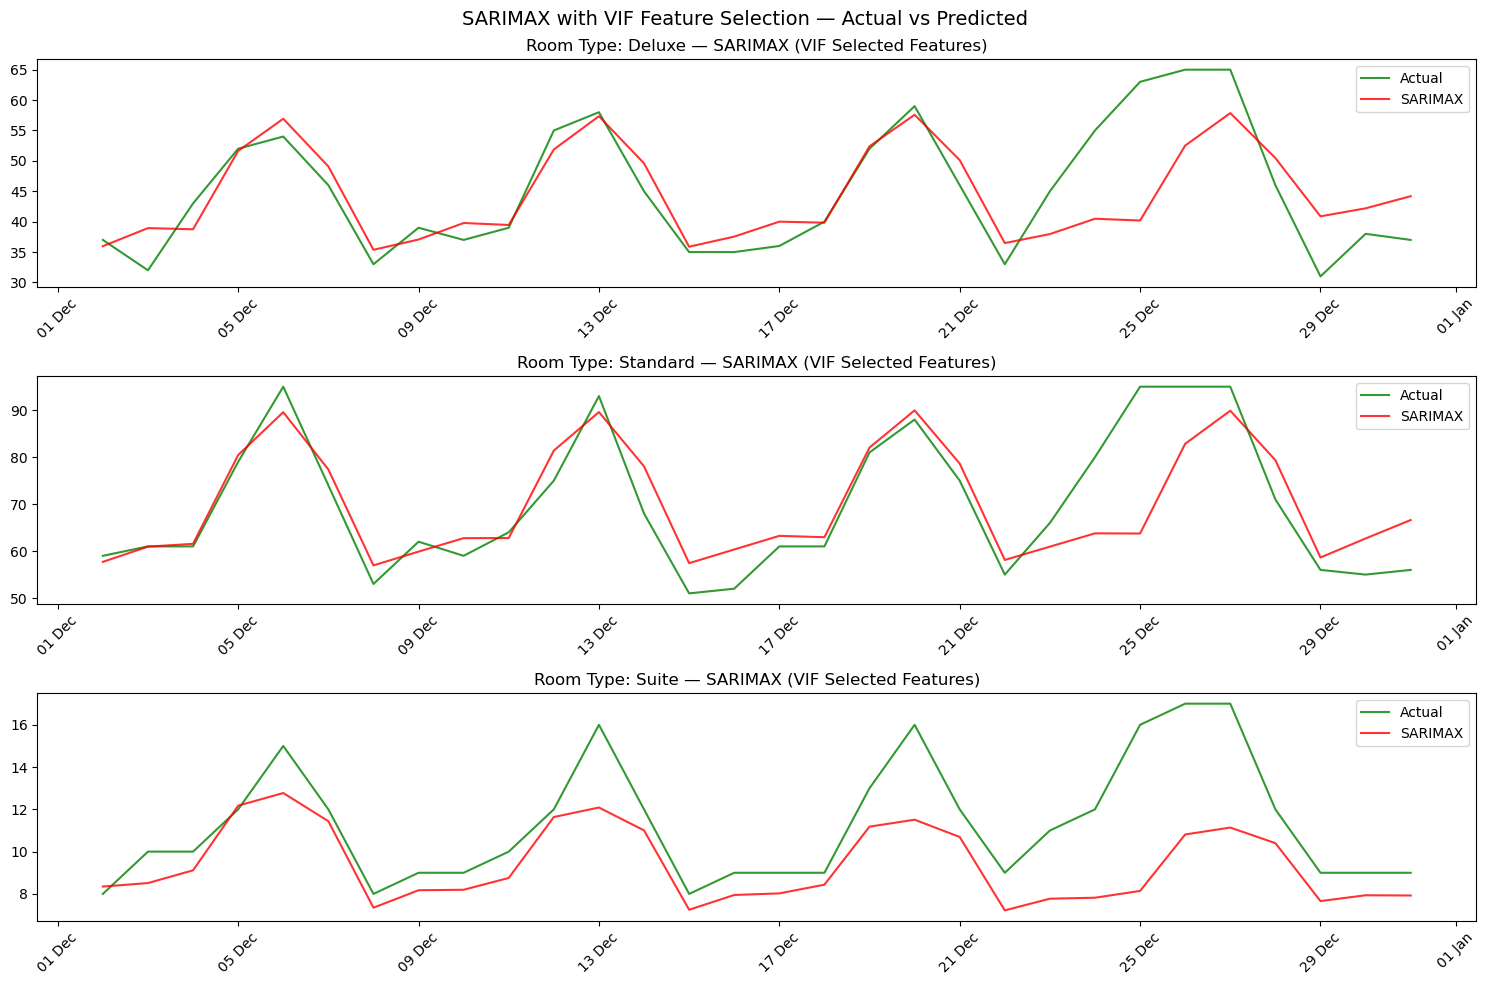

In [24]:
# ── Plot ──────────────────────────────────────────────────────────────────────
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(15, 10))
for ax, (room_name, res) in zip(axes, sarimax_results.items()):
    ax.plot(res['actual'].index, res['actual'].values,
            label='Actual', color='green', alpha=0.8)
    ax.plot(res['actual'].index, res['preds'].values,
            label='SARIMAX', color='red', alpha=0.8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.tick_params(axis='x', rotation=45)
    ax.set_title(f"Room Type: {room_name} — SARIMAX (VIF Selected Features)")
    ax.legend()

plt.suptitle("SARIMAX with VIF Feature Selection — Actual vs Predicted", fontsize=14)
plt.tight_layout()
plt.show()

In [19]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [20]:
exog_features = ['day_of_week','is_weekend', 'month', 'week',
                   'price_lag_1', 'price_lag_7', 'price_rolling_7',
                      'event_name_Diwali', 'event_name_New Year',
                        'event_name_Tamil New Year', "event_name_Valentine's Day"
]

In [22]:
for col in exog_features:
    train_df[col] = train_df[col].astype(float)
    val_df[col]   = val_df[col].astype(float)

In [23]:
for col in exog_features:
    print(col, train_df[col].dtype, train_df[col].dtype == object)

day_of_week float64 False
is_weekend float64 False
month float64 False
week float64 False
price_lag_1 float64 False
price_lag_7 float64 False
price_rolling_7 float64 False
event_name_Diwali float64 False
event_name_New Year float64 False
event_name_Tamil New Year float64 False
event_name_Valentine's Day float64 False


In [24]:

# ── Fit one ARIMAX per room type ─────────────────────────────────────────────
arimax_results = {}
room_names = {0: 'Deluxe', 1: 'Standard', 2: 'Suite'}

for room_code, room_name in room_names.items():
    print(f"\nFitting ARIMAX for: {room_name}")
    
    train = train_df[train_df['room_type'] == room_code].set_index('date').asfreq('D')
    val   = val_df[val_df['room_type'] == room_code].set_index('date').asfreq('D')
    
    model = SARIMAX(
        train['bookings'],
        exog=train[exog_features],
        order=(1, 1, 1),
        seasonal_order=(1, 0, 1, 7),  # weekly seasonality
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    fitted = model.fit(disp=False)
    
    preds = fitted.forecast(steps=len(val), exog=val[exog_features])
    preds = np.clip(preds, 0, None)
    
    mae  = mean_absolute_error(val['bookings'], preds)
    rmse = np.sqrt(mean_squared_error(val['bookings'], preds))
    mape = np.mean(np.abs((val['bookings'] - preds) / val['bookings'].clip(lower=1))) * 100
    
    arimax_results[room_name] = {
        'MAE': mae, 'RMSE': rmse, 'MAPE': mape,
        'model': fitted, 'preds': preds, 'actual': val['bookings']
    }
    print(f"  MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.1f}%")

# ── Overall metrics across all room types ────────────────────────────────────
all_actual = np.concatenate([v['actual'].values for v in arimax_results.values()])
all_preds  = np.concatenate([v['preds'].values  for v in arimax_results.values()])

print("\n── Overall ARIMAX ───────────────────────────────────────────────────")
print(f"MAE:  {mean_absolute_error(all_actual, all_preds):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(all_actual, all_preds)):.2f}")
print(f"MAPE: {np.mean(np.abs((all_actual - all_preds) / all_actual.clip(0.1))) * 100:.1f}%")




Fitting ARIMAX for: Deluxe
  MAE: 3.58 | RMSE: 5.22 | MAPE: 7.9%

Fitting ARIMAX for: Standard
  MAE: 5.12 | RMSE: 6.98 | MAPE: 7.2%

Fitting ARIMAX for: Suite
  MAE: 1.35 | RMSE: 2.01 | MAPE: 10.5%

── Overall ARIMAX ───────────────────────────────────────────────────
MAE:  3.35
RMSE: 5.17
MAPE: 8.5%


In [39]:
#print(arimax_results['Deluxe']['preds'].index)

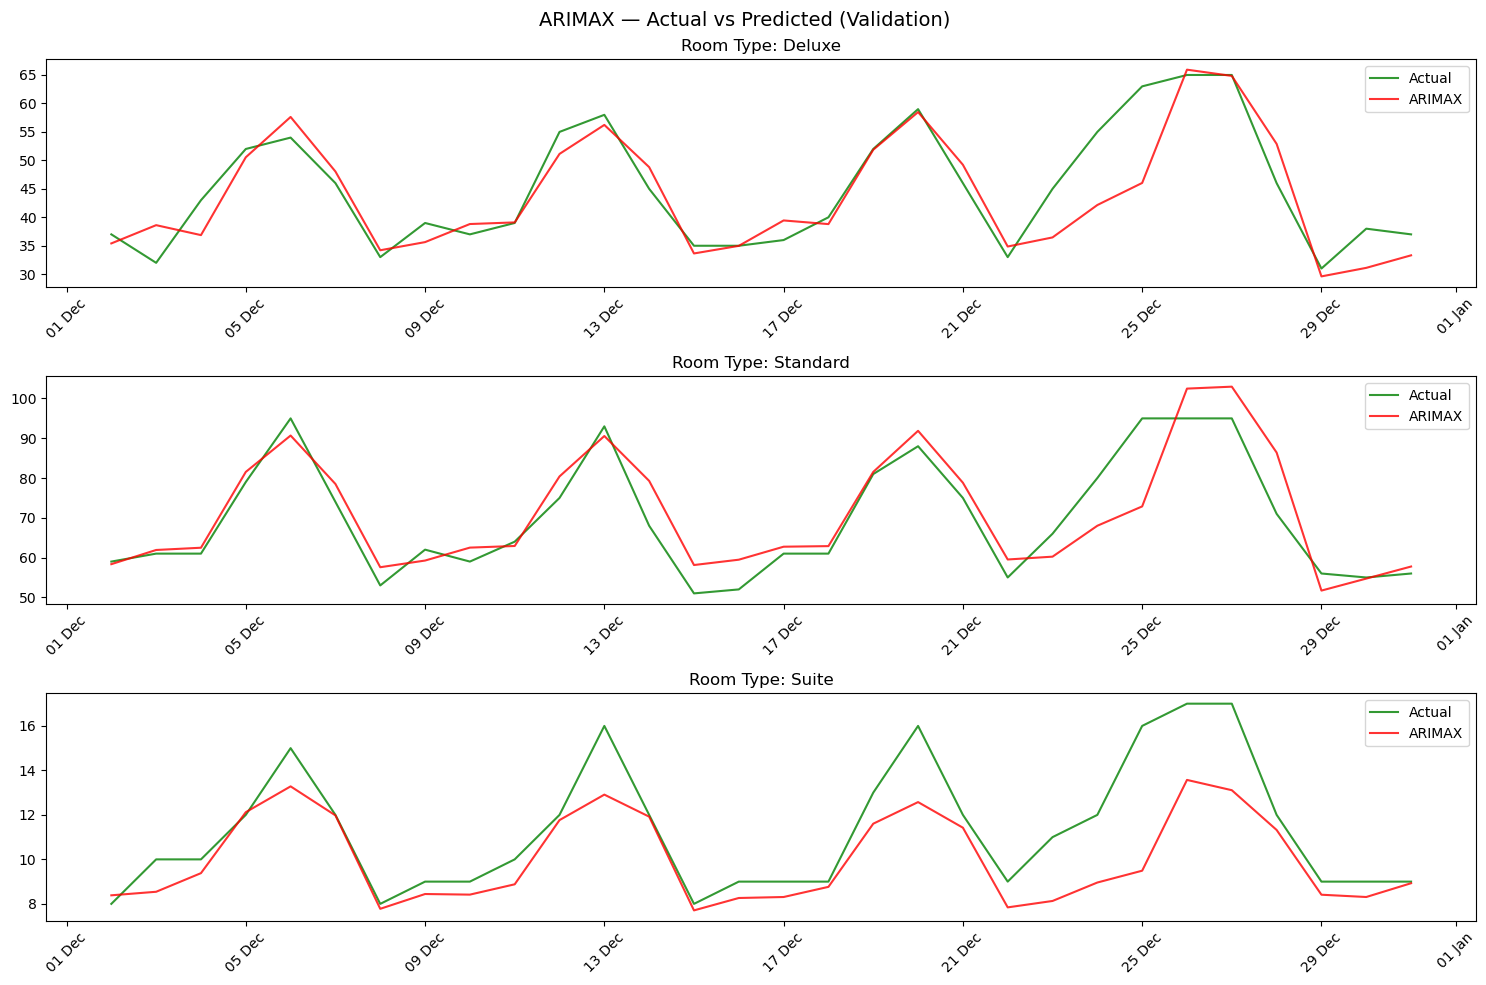

In [38]:
# ── Plot per room type ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

for ax, (room_name, res) in zip(axes, arimax_results.items()):
    ax.plot(res['actual'].index, res['actual'].values, label='Actual',  color='green', alpha=0.8)
    ax.plot(res['actual'].index, res['preds'].values,  label='ARIMAX',  color='red',   alpha=0.8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.tick_params(axis='x', rotation=45)
    ax.set_title(f"Room Type: {room_name}")
    ax.legend()

plt.suptitle("ARIMAX — Actual vs Predicted (Validation)", fontsize=14)
plt.tight_layout()
plt.show()

In [40]:
import itertools

# ── Grid search for best ARIMAX order ────────────────────────────────────────
p_values = [0, 1, 2]
d_values = [0, 1]
q_values = [0, 1, 2]

best_overall = {'mae': np.inf, 'order': None}
room_names = {0: 'Deluxe', 1: 'Standard', 2: 'Suite'}

for room_code, room_name in room_names.items():
    print(f"\nTuning ARIMAX for: {room_name}")
    
    train = train_df[train_df['room_type'] == room_code].set_index('date').asfreq('D')
    val   = val_df[val_df['room_type'] == room_code].set_index('date').asfreq('D')
    
    best = {'mae': np.inf, 'order': None, 'preds': None}
    
    for p, d, q in itertools.product(p_values, d_values, q_values):
        try:
            model = SARIMAX(
                train['bookings'],
                exog=train[exog_features],
                order=(p, d, q),
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            fitted = model.fit(disp=False)
            
            preds = np.clip(
                fitted.forecast(steps=len(val), exog=val[exog_features]), 0, None
            )
            mae = mean_absolute_error(val['bookings'], preds)
            
            if mae < best['mae']:
                best = {'mae': mae, 'order': (p, d, q), 
                        'preds': preds, 'model': fitted}
        except:
            continue
    
    rmse = np.sqrt(mean_squared_error(val['bookings'], best['preds']))
    mape = np.mean(np.abs((val['bookings'] - best['preds']) / 
                           val['bookings'].clip(lower=1))) * 100
    
    print(f"  Best order: {best['order']}")
    print(f"  MAE: {best['mae']:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.1f}%")
    
    room_names[room_code] = {
        'name': room_name, **best,
        'actual': val['bookings'], 'rmse': rmse, 'mape': mape
    }

# ── Overall metrics ───────────────────────────────────────────────────────────
all_actual = np.concatenate([v['actual'].values for v in room_names.values()])
all_preds  = np.concatenate([v['preds'].values  for v in room_names.values()])

print("\n── Overall Tuned ARIMAX (no seasonality) ────────────────────────────")
print(f"MAE:  {mean_absolute_error(all_actual, all_preds):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(all_actual, all_preds)):.2f}")
print(f"MAPE: {np.mean(np.abs((all_actual - all_preds) / all_actual.clip(0.1))) * 100:.1f}%")




Tuning ARIMAX for: Deluxe
  Best order: (0, 1, 1)
  MAE: 5.18 | RMSE: 6.53 | MAPE: 11.0%

Tuning ARIMAX for: Standard
  Best order: (2, 0, 2)
  MAE: 6.21 | RMSE: 8.83 | MAPE: 8.6%

Tuning ARIMAX for: Suite
  Best order: (2, 1, 1)
  MAE: 1.38 | RMSE: 1.78 | MAPE: 11.6%

── Overall Tuned ARIMAX (no seasonality) ────────────────────────────
MAE:  4.26
RMSE: 6.42
MAPE: 10.4%


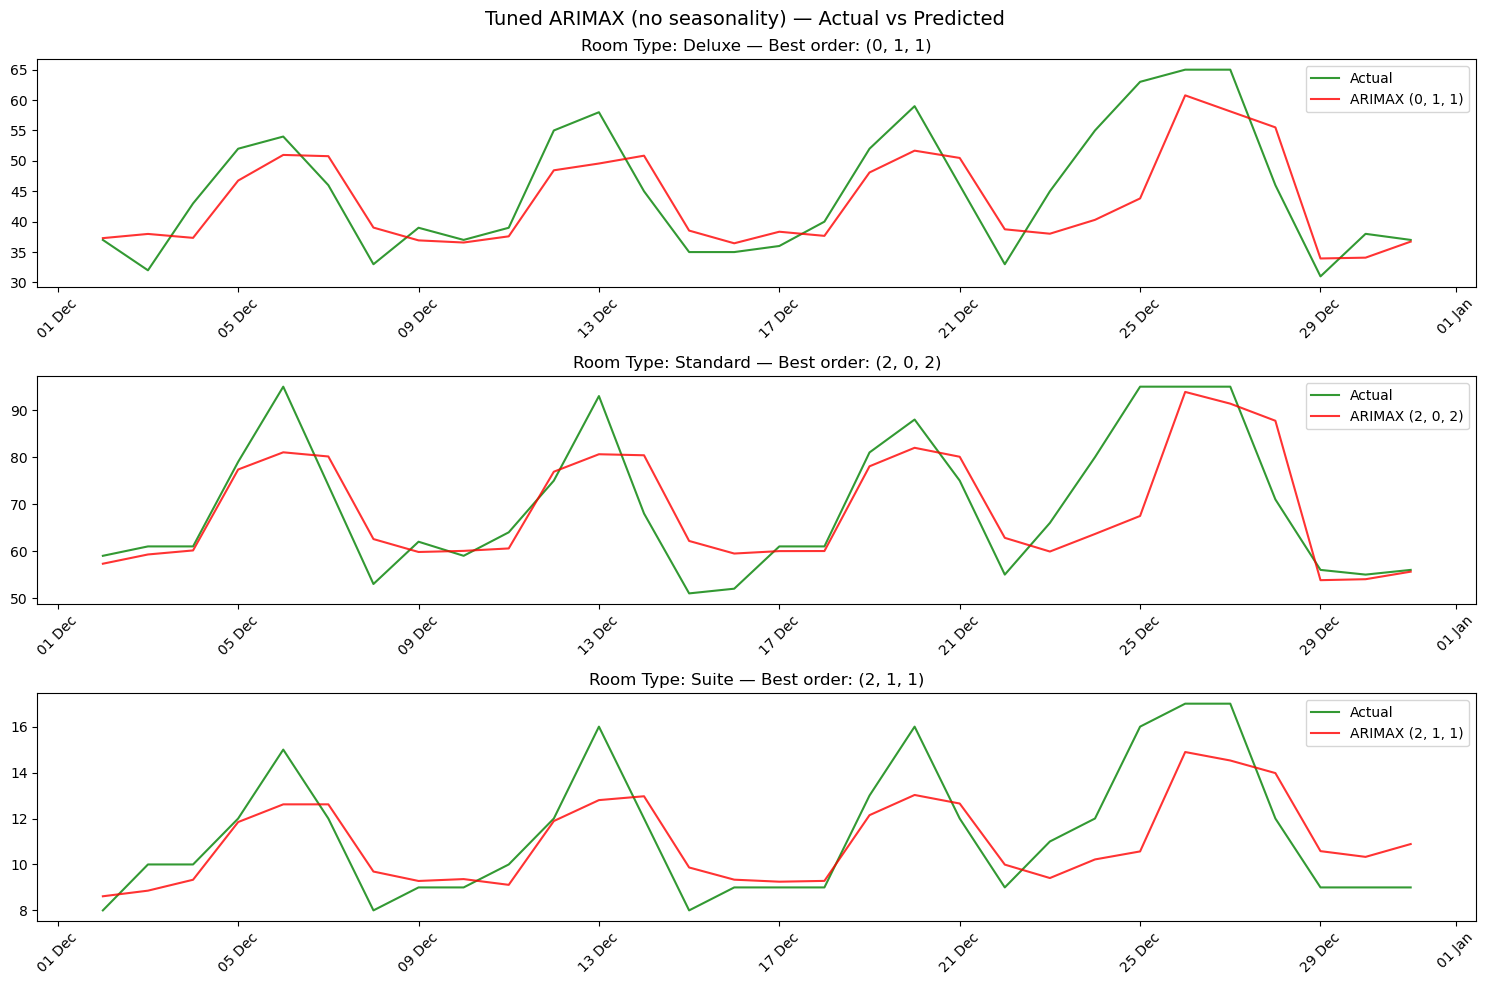

In [42]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

for ax, (room_code, res) in zip(axes, room_names.items()):
    ax.plot(res['actual'].index, res['actual'].values, 
            label='Actual', color='green', alpha=0.8)
    ax.plot(res['actual'].index, res['preds'].values,  
            label=f"ARIMAX {res['order']}", color='red', alpha=0.8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.tick_params(axis='x', rotation=45)
    ax.set_title(f"Room Type: {res['name']} — Best order: {res['order']}")
    ax.legend()

plt.suptitle("Tuned ARIMAX (no seasonality) — Actual vs Predicted", fontsize=14)
plt.tight_layout()
plt.show()

In [48]:
# ── Rename columns with spaces/special chars ──────────────────────────────────
rename_map = {
    'event_name_New Year':        'event_name_New_Year',
    'event_name_Tamil New Year':  'event_name_Tamil_New_Year',
    "event_name_Valentine's Day": 'event_name_Valentines_Day'
}
train_df = train_df.rename(columns=rename_map)
val_df   = val_df.rename(columns=rename_map)
df       = df.rename(columns=rename_map)



In [53]:
from prophet import Prophet
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Exog features for Prophet (regressors) ───────────────────────────────────
regressor_features = [
    'is_weekend', 'month', 'week',
    'price_lag_1', 'price_lag_7', 'price_rolling_7',
    'event_name_Diwali',
    'event_name_New_Year',
    'event_name_Tamil_New_Year',
    'event_name_Valentines_Day'
]

prophet_results = {}
room_names = {0: 'Deluxe', 1: 'Standard', 2: 'Suite'}
for room_code, room_name in room_names.items():
    print(f"\nFitting Prophet for: {room_name}")
    train = train_df[train_df['room_type'] == room_code].copy().reset_index(drop=True)
    val   = val_df[val_df['room_type'] == room_code].copy().reset_index(drop=True)

    train_prophet = pd.DataFrame({
        'ds': train['date'].values.astype('datetime64[ns]'),  # ← fix
        'y':  train['bookings'].values.astype(float)
    })
    val_prophet = pd.DataFrame({
        'ds': val['date'].values.astype('datetime64[ns]'),    # ← fix
        'y':  val['bookings'].values.astype(float)
    })

    for col in regressor_features:
        train_prophet[col] = train[col].values.astype(float)
        val_prophet[col]   = val[col].values.astype(float)

    # rest of the code stays the same ...
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode='multiplicative'
    )
    for col in regressor_features:
        model.add_regressor(col)

    model.fit(train_prophet)

    preds_df = model.predict(val_prophet)
    preds    = np.clip(preds_df['yhat'].values, 0, None)

    mae  = mean_absolute_error(val_prophet['y'], preds)
    rmse = np.sqrt(mean_squared_error(val_prophet['y'], preds))
    mape = np.mean(np.abs((val_prophet['y'] - preds) /
                           val_prophet['y'].clip(lower=1))) * 100

    prophet_results[room_name] = {
        'mae': mae, 'rmse': rmse, 'mape': mape,
        'preds': preds, 'actual': val_prophet['y'].values,
        'dates': val_prophet['ds'].values
    }
    print(f"  MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.1f}%")
# ── Overall metrics ───────────────────────────────────────────────────────────
all_actual = np.concatenate([v['actual'] for v in prophet_results.values()])
all_preds  = np.concatenate([v['preds']  for v in prophet_results.values()])

print("\n── Overall Prophet ──────────────────────────────────────────────────")
print(f"MAE:  {mean_absolute_error(all_actual, all_preds):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(all_actual, all_preds)):.2f}")
print(f"MAPE: {np.mean(np.abs((all_actual - all_preds) / all_actual.clip(0.1))) * 100:.1f}%")




Fitting Prophet for: Deluxe


ValueError: cannot reindex on an axis with duplicate labels

In [ ]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

for ax, (room_name, res) in zip(axes, prophet_results.items()):
    ax.plot(res['dates'], res['actual'], label='Actual', color='green', alpha=0.8)
    ax.plot(res['dates'], res['preds'],  label='Prophet', color='red',  alpha=0.8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.tick_params(axis='x', rotation=45)
    ax.set_title(f"Room Type: {room_name}")
    ax.legend()

plt.suptitle("Prophet — Actual vs Predicted (Validation)", fontsize=14)
plt.tight_layout()
plt.show()